In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import joblib
import pandas as pd


Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")


In [ ]:
# Confirm everything is where we expect
print("DATA_DIR contents:", os.listdir(DATA_DIR))

DATA_DIR contents: ['bangla_smishing_preprocessed.csv', 'test.csv', 'train.csv', 'validation.csv', 'train_processed.csv', 'test_processed.csv', 'val_processed.csv']


In [ ]:
CONFIG_PATH = os.path.join(RESULTS_DIR, "preprocessing_config.json")

In [ ]:
with open(CONFIG_PATH) as f:
    config = json.load(f)

print(json.dumps(config, indent=2)[:1000])


{
  "model_name": "csebuetnlp/banglabert",
  "label2id": {
    "normal": 0,
    "promo": 1,
    "smish": 2
  },
  "id2label": {
    "0": "normal",
    "1": "promo",
    "2": "smish"
  },
  "structured_feature_columns": [
    "url_count",
    "url_total_length",
    "url_max_length",
    "url_digit_count",
    "url_dot_count",
    "url_hyphen_count",
    "url_slash_count",
    "url_has_https",
    "url_has_ip",
    "url_has_at",
    "url_is_shortened",
    "phone_count",
    "has_phone",
    "digit_count",
    "number_count",
    "has_digits",
    "char_count",
    "word_count",
    "exclamation_count",
    "question_count",
    "comma_count",
    "dot_count",
    "colon_count",
    "special_char_count",
    "currency_count",
    "has_currency",
    "security_keyword_count",
    "has_security_keyword",
    "bangla_char_count",
    "english_char_count",
    "bangla_ratio",
    "english_ratio",
    "has_bangla",
    "has_english"
  ],
  "scaled_feature_columns": [
    "scaled_url_count",


In [ ]:
import os
import pandas as pd

print("DATA_DIR:", os.listdir(DATA_DIR))
print("MODEL_DIR:", os.listdir(MODEL_DIR) if os.path.exists(MODEL_DIR) else "does not exist")

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print("\nColumns:", train_df.columns.tolist())
print("\nShape:", train_df.shape)
print("\nFirst row text_for_model:", train_df["text_for_model"].iloc[0] if "text_for_model" in train_df.columns else "column not found")
print("\nlabel_id value counts:")
print(train_df["label_id"].value_counts() if "label_id" in train_df.columns else "column not found")

DATA_DIR: ['bangla_smishing_preprocessed.csv', 'test.csv', 'train.csv', 'validation.csv', 'train_processed.csv', 'test_processed.csv', 'val_processed.csv']
MODEL_DIR: ['banglabert_tokenizer', 'structured_feature_scaler.pkl']

Columns: ['label', 'text', 'source', 'has_url', 'label_id', 'text_original', 'text_normalized', 'urls', 'url_count', 'url_count.1', 'url_total_length', 'url_max_length', 'url_digit_count', 'url_dot_count', 'url_hyphen_count', 'url_slash_count', 'url_has_https', 'url_has_ip', 'url_has_at', 'url_is_shortened', 'text_for_model', 'character_length', 'url_count.2', 'url_total_length.1', 'url_max_length.1', 'url_digit_count.1', 'url_dot_count.1', 'url_hyphen_count.1', 'url_slash_count.1', 'url_has_https.1', 'url_has_ip.1', 'url_has_at.1', 'url_is_shortened.1', 'url_count.3', 'url_total_length.2', 'url_max_length.2', 'url_digit_count.2', 'url_dot_count.2', 'url_hyphen_count.2', 'url_slash_count.2', 'url_has_https.2', 'url_has_ip.2', 'url_has_at.2', 'url_is_shortened.2', 

In [ ]:
proc_df = pd.read_csv(os.path.join(DATA_DIR, "train_processed.csv"))
print("Shape:", proc_df.shape)
print("\nColumns:", proc_df.columns.tolist())
print("\nDuplicate columns:", proc_df.columns[proc_df.columns.duplicated()].tolist())
print("\nHas scaled_ columns:", [c for c in proc_df.columns if c.startswith("scaled_")][:5])

Shape: (1002, 126)

Columns: ['label', 'text', 'source', 'has_url', 'label_id', 'text_original', 'text_normalized', 'urls', 'url_count', 'url_count.1', 'url_total_length', 'url_max_length', 'url_digit_count', 'url_dot_count', 'url_hyphen_count', 'url_slash_count', 'url_has_https', 'url_has_ip', 'url_has_at', 'url_is_shortened', 'text_for_model', 'character_length', 'url_count.2', 'url_total_length.1', 'url_max_length.1', 'url_digit_count.1', 'url_dot_count.1', 'url_hyphen_count.1', 'url_slash_count.1', 'url_has_https.1', 'url_has_ip.1', 'url_has_at.1', 'url_is_shortened.1', 'text_unicode', 'text_clean', 'phone_count', 'has_phone', 'digit_count', 'number_count', 'has_digits', 'char_count', 'word_count', 'exclamation_count', 'question_count', 'comma_count', 'dot_count', 'colon_count', 'special_char_count', 'currency_count', 'has_currency', 'security_keyword_count', 'has_security_keyword', 'bangla_char_count', 'english_char_count', 'bangla_ratio', 'english_ratio', 'has_bangla', 'has_engli

In [ ]:
# ============================================================
# Cell 1a — Clean up duplicated columns in *_processed.csv
# Run this ONCE. Saves clean files back to Drive so every
# future notebook (baseline, BanglaBERT, etc.) can just load
# the clean versions directly.
# ============================================================
import os
import json
import numpy as np
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

with open(os.path.join(RESULTS_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

EXPECTED_RAW = config["structured_feature_columns"]     # 34 names, no suffixes
EXPECTED_SCALED = config["scaled_feature_columns"]       # 34 names, no suffixes
TEXT_COL = "text_for_model"
LABEL_COL = "label_id"


def dedupe_columns(df, expected_base_names, label=""):
    """
    For each expected base name, find all its variants (name, name.1, name.2...),
    verify they're identical, keep only the first occurrence, drop the rest.
    """
    dropped = []
    mismatches = []
    for base in expected_base_names:
        variants = [c for c in df.columns if c == base or c.startswith(base + ".")]
        if len(variants) <= 1:
            continue  # not duplicated, nothing to do
        canonical = variants[0]
        for dup in variants[1:]:
            if df[canonical].equals(df[dup]):
                dropped.append(dup)
            else:
                # not identical — flag it, don't silently drop
                n_diff = (df[canonical] != df[dup]).sum()
                mismatches.append((canonical, dup, n_diff))
    if mismatches:
        print(f"⚠️  [{label}] MISMATCHED duplicates found (NOT auto-dropped, needs manual review):")
        for canonical, dup, n_diff in mismatches:
            print(f"    {canonical} vs {dup}: {n_diff} differing rows")
    if dropped:
        df = df.drop(columns=dropped)
        print(f"[{label}] Dropped {len(dropped)} confirmed-identical duplicate columns.")
    return df


def clean_split(name):
    path = os.path.join(DATA_DIR, f"{name}_processed.csv")
    df = pd.read_csv(path)
    print(f"\n=== {name} ===  original shape: {df.shape}")

    df = dedupe_columns(df, EXPECTED_RAW, label=f"{name}/raw")
    df = dedupe_columns(df, EXPECTED_SCALED, label=f"{name}/scaled")

    # Verify we now have exactly the expected columns, no more, no less
    missing_raw = [c for c in EXPECTED_RAW if c not in df.columns]
    missing_scaled = [c for c in EXPECTED_SCALED if c not in df.columns]
    if missing_raw or missing_scaled:
        print(f"❌ Still missing columns — raw: {missing_raw}, scaled: {missing_scaled}")
    else:
        print(f"✅ All {len(EXPECTED_RAW)} raw + {len(EXPECTED_SCALED)} scaled features present, no duplicates.")

    print(f"Cleaned shape: {df.shape}")

    out_path = os.path.join(DATA_DIR, f"{name}_clean.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved -> {out_path}")
    return df


train_df = clean_split("train")
val_df   = clean_split("val")
test_df  = clean_split("test")

# ------------------------------------------------------------
# Quick label sanity check across splits
# ------------------------------------------------------------
print("\nLabel distribution:")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}:", df[LABEL_COL].value_counts().to_dict())


=== train ===  original shape: (1002, 126)
[train/raw] Dropped 12 confirmed-identical duplicate columns.
[train/scaled] Dropped 34 confirmed-identical duplicate columns.
✅ All 34 raw + 34 scaled features present, no duplicates.
Cleaned shape: (1002, 80)
Saved -> /content/drive/MyDrive/Bangla_Smishing_Project/dataset/train_clean.csv

=== val ===  original shape: (125, 126)
[val/raw] Dropped 12 confirmed-identical duplicate columns.
[val/scaled] Dropped 34 confirmed-identical duplicate columns.
✅ All 34 raw + 34 scaled features present, no duplicates.
Cleaned shape: (125, 80)
Saved -> /content/drive/MyDrive/Bangla_Smishing_Project/dataset/val_clean.csv

=== test ===  original shape: (126, 126)
[test/raw] Dropped 12 confirmed-identical duplicate columns.
[test/scaled] Dropped 34 confirmed-identical duplicate columns.
✅ All 34 raw + 34 scaled features present, no duplicates.
Cleaned shape: (126, 80)
Saved -> /content/drive/MyDrive/Bangla_Smishing_Project/dataset/test_clean.csv

Label dist

Shapes: (1002, 80) (124, 80) (124, 80)
Class weights: {np.int64(0): np.float64(0.925207756232687), np.int64(1): np.float64(1.363265306122449), np.int64(2): np.float64(0.8434343434343434)}


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Validation ===
Accuracy: 0.9274 | Macro Precision: 0.9324 | Macro Recall: 0.9309 | Macro F1: 0.9300
              precision    recall  f1-score   support

      normal       0.97      0.87      0.92        45
       promo       0.94      0.97      0.95        31
       smish       0.88      0.96      0.92        48

    accuracy                           0.93       124
   macro avg       0.93      0.93      0.93       124
weighted avg       0.93      0.93      0.93       124



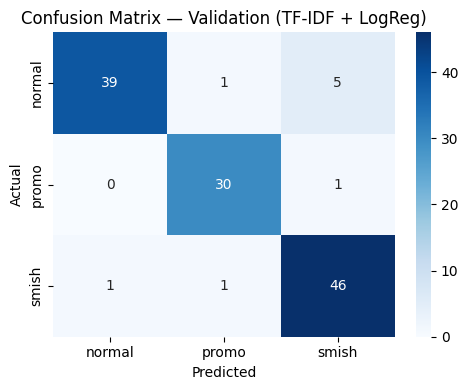

Smishing recall: 0.9583 | Smishing->Normal errors: 1/48

=== Test ===
Accuracy: 0.8952 | Macro Precision: 0.8961 | Macro Recall: 0.8951 | Macro F1: 0.8933
              precision    recall  f1-score   support

      normal       0.97      0.84      0.90        45
       promo       0.85      0.90      0.88        31
       smish       0.87      0.94      0.90        48

    accuracy                           0.90       124
   macro avg       0.90      0.90      0.89       124
weighted avg       0.90      0.90      0.90       124



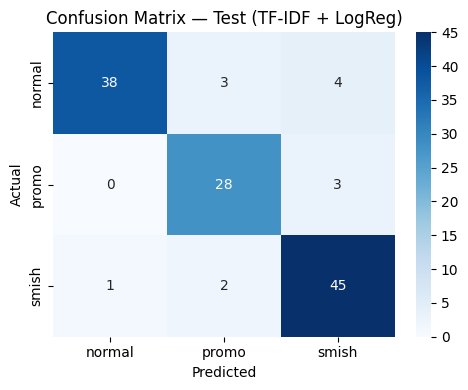

Smishing recall: 0.9375 | Smishing->Normal errors: 1/48

Logged to /content/drive/MyDrive/Bangla_Smishing_Project/results/metrics.csv
Saved model + vectorizer to /content/drive/MyDrive/Bangla_Smishing_Project/models/tfidf_baseline


In [ ]:
# ============================================================
# Cell 2 — Step 1 Baseline: TF-IDF + Logistic Regression
# Uses the clean, deduplicated files
# ============================================================
import os
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

TEXT_COL = "text_for_model"
LABEL_COL = "label_id"
ID2LABEL = {0: "normal", 1: "promo", 2: "smish"}

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_clean.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_final.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_final.csv"))

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)

# ------------------------------------------------------------
# TF-IDF on text only (structured features come in Step 1b / BanglaBERT-dual-input later)
# ------------------------------------------------------------
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df[TEXT_COL])
X_val   = vectorizer.transform(val_df[TEXT_COL])
X_test  = vectorizer.transform(test_df[TEXT_COL])

y_train, y_val, y_test = train_df[LABEL_COL], val_df[LABEL_COL], test_df[LABEL_COL]

classes = np.array(sorted(y_train.unique()))
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

clf = LogisticRegression(max_iter=2000, class_weight=class_weight, multi_class="multinomial", C=1.0)
clf.fit(X_train, y_train)

def evaluate(split_name, X, y_true):
    y_pred = clf.predict(X)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n=== {split_name} ===")
    print(f"Accuracy: {acc:.4f} | Macro Precision: {precision:.4f} | Macro Recall: {recall:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=[ID2LABEL[i] for i in sorted(ID2LABEL)], zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=sorted(ID2LABEL))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)],
                yticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)])
    plt.title(f"Confusion Matrix — {split_name} (TF-IDF + LogReg)")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    smish_mask = (y_true == 2)
    smish_recall = (y_pred[smish_mask] == 2).mean() if smish_mask.sum() else float("nan")
    smish_to_normal = int(((y_true == 2) & (y_pred == 0)).sum())
    print(f"Smishing recall: {smish_recall:.4f} | Smishing->Normal errors: {smish_to_normal}/{smish_mask.sum()}")

    return {"split": split_name, "accuracy": acc, "macro_precision": precision,
            "macro_recall": recall, "macro_f1": f1, "smish_recall": smish_recall}

val_metrics = evaluate("Validation", X_val, y_val.values)
test_metrics = evaluate("Test", X_test, y_test.values)

# ------------------------------------------------------------
# Log + save
# ------------------------------------------------------------
os.makedirs(RESULTS_DIR, exist_ok=True)
results_path = os.path.join(RESULTS_DIR, "metrics.csv")
row = {"model": "TF-IDF + Logistic Regression (text only)", **test_metrics}
if os.path.exists(results_path):
    results_df = pd.concat([pd.read_csv(results_path), pd.DataFrame([row])], ignore_index=True)
else:
    results_df = pd.DataFrame([row])
results_df.to_csv(results_path, index=False)
print(f"\nLogged to {results_path}")

baseline_dir = os.path.join(MODEL_DIR, "tfidf_baseline")
os.makedirs(baseline_dir, exist_ok=True)
joblib.dump(clf, os.path.join(baseline_dir, "logreg_model.pkl"))
joblib.dump(vectorizer, os.path.join(baseline_dir, "tfidf_vectorizer.pkl"))
print(f"Saved model + vectorizer to {baseline_dir}")

Using 34 scaled structured features


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Validation (text + structured) ===
Accuracy: 0.9032 | Macro F1: 0.8991
              precision    recall  f1-score   support

      normal       0.91      0.96      0.93        45
       promo       0.82      0.90      0.86        31
       smish       0.95      0.85      0.90        48

    accuracy                           0.90       124
   macro avg       0.90      0.90      0.90       124
weighted avg       0.91      0.90      0.90       124



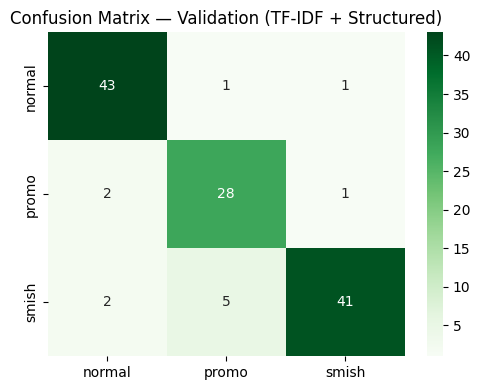


=== Test (text + structured) ===
Accuracy: 0.9516 | Macro F1: 0.9500
              precision    recall  f1-score   support

      normal       0.96      0.98      0.97        45
       promo       0.94      0.94      0.94        31
       smish       0.96      0.94      0.95        48

    accuracy                           0.95       124
   macro avg       0.95      0.95      0.95       124
weighted avg       0.95      0.95      0.95       124



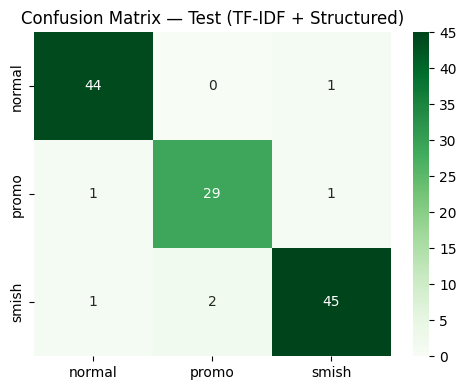


COMPARISON: text-only vs text+structured
Text-only macro F1 (test):        0.8933
Text+structured macro F1 (test):  0.9500

Logged to /content/drive/MyDrive/Bangla_Smishing_Project/results/metrics.csv


In [ ]:
# ============================================================
# Cell 3 — Step 1b: TF-IDF + Structured Features (concat) baseline
# Tests whether the 34 URL/text structured features add value
# on top of text alone. Cheap to run, no GPU needed.
# ============================================================
import os
import numpy as np
import pandas as pd
import joblib
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

TEXT_COL = "text_for_model"
LABEL_COL = "label_id"
ID2LABEL = {0: "normal", 1: "promo", 2: "smish"}

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_clean.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_final.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_final.csv"))

SCALED_COLS = [c for c in train_df.columns if c.startswith("scaled_")]
print(f"Using {len(SCALED_COLS)} scaled structured features")

# ------------------------------------------------------------
# Reuse the SAME TF-IDF vectorizer fit already saved from Step 1
# (fair comparison — identical text representation, only adding features)
# ------------------------------------------------------------
vectorizer = joblib.load(os.path.join(MODEL_DIR, "tfidf_baseline", "tfidf_vectorizer.pkl"))

X_train_text = vectorizer.transform(train_df[TEXT_COL])
X_val_text   = vectorizer.transform(val_df[TEXT_COL])
X_test_text  = vectorizer.transform(test_df[TEXT_COL])

X_train_struct = csr_matrix(train_df[SCALED_COLS].values)
X_val_struct   = csr_matrix(val_df[SCALED_COLS].values)
X_test_struct  = csr_matrix(test_df[SCALED_COLS].values)

X_train = hstack([X_train_text, X_train_struct]).tocsr()
X_val   = hstack([X_val_text, X_val_struct]).tocsr()
X_test  = hstack([X_test_text, X_test_struct]).tocsr()

y_train, y_val, y_test = train_df[LABEL_COL], val_df[LABEL_COL], test_df[LABEL_COL]

classes = np.array(sorted(y_train.unique()))
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

clf = LogisticRegression(max_iter=2000, class_weight=class_weight, multi_class="multinomial", C=1.0)
clf.fit(X_train, y_train)

def evaluate(split_name, X, y_true):
    y_pred = clf.predict(X)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n=== {split_name} (text + structured) ===")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=[ID2LABEL[i] for i in sorted(ID2LABEL)], zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=sorted(ID2LABEL))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)],
                yticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)])
    plt.title(f"Confusion Matrix — {split_name} (TF-IDF + Structured)")
    plt.tight_layout()
    plt.show()

    smish_mask = (y_true == 2)
    smish_recall = (y_pred[smish_mask] == 2).mean() if smish_mask.sum() else float("nan")
    return {"split": split_name, "accuracy": acc, "macro_f1": f1, "smish_recall": smish_recall}

val_metrics = evaluate("Validation", X_val, y_val.values)
test_metrics = evaluate("Test", X_test, y_test.values)

# ------------------------------------------------------------
# Compare directly against the text-only baseline
# ------------------------------------------------------------
results_path = os.path.join(RESULTS_DIR, "metrics.csv")
prior = pd.read_csv(results_path)
text_only_row = prior[prior["model"].str.contains("text only", case=False, na=False)]

print("\n" + "="*50)
print("COMPARISON: text-only vs text+structured")
print("="*50)
if not text_only_row.empty:
    prior_f1 = text_only_row.iloc[-1]["macro_f1"]
    print(f"Text-only macro F1 (test):        {prior_f1:.4f}")
print(f"Text+structured macro F1 (test):  {test_metrics['macro_f1']:.4f}")

row = {"model": "TF-IDF + Structured Features", **test_metrics}
results_df = pd.concat([prior, pd.DataFrame([row])], ignore_index=True)
results_df.to_csv(results_path, index=False)
print(f"\nLogged to {results_path}")

Device: cuda
Structured features: 34 (enabled)


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Class weights: {np.int64(0): np.float64(0.925207756232687), np.int64(1): np.float64(1.363265306122449), np.int64(2): np.float64(0.8434343434343434)}
Epoch 1/12 | Train loss 1.0423 F1 0.4978 | Val loss 0.7939 Acc 0.9440 F1 0.9421
  -> New best model saved (val F1 0.9421)
Epoch 2/12 | Train loss 0.4790 F1 0.9377 | Val loss 0.2253 Acc 0.9600 F1 0.9575
  -> New best model saved (val F1 0.9575)
Epoch 3/12 | Train loss 0.1722 F1 0.9783 | Val loss 0.1469 Acc 0.9680 F1 0.9665
  -> New best model saved (val F1 0.9665)
Epoch 4/12 | Train loss 0.0942 F1 0.9867 | Val loss 0.1175 Acc 0.9680 F1 0.9664
Epoch 5/12 | Train loss 0.0529 F1 0.9949 | Val loss 0.0904 Acc 0.9760 F1 0.9735
  -> New best model saved (val F1 0.9735)
Epoch 6/12 | Train loss 0.0307 F1 0.9978 | Val loss 0.0802 Acc 0.9840 F1 0.9821
  -> New best model saved (val F1 0.9821)
Epoch 7/12 | Train loss 0.0258 F1 0.9989 | Val loss 0.1045 Acc 0.9760 F1 0.9735
Epoch 8/12 | Train loss 0.0222 F1 0.9989 | Val loss 0.1008 Acc 0.9760 F1 0.9735
E

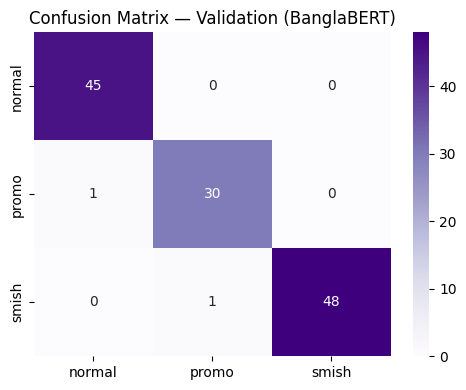

Smishing recall: 0.9796

=== Test (BanglaBERT dual-input) ===
Accuracy: 0.9683 | Macro F1: 0.9668
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99        45
       promo       0.97      0.94      0.95        31
       smish       0.94      0.98      0.96        50

    accuracy                           0.97       126
   macro avg       0.97      0.96      0.97       126
weighted avg       0.97      0.97      0.97       126



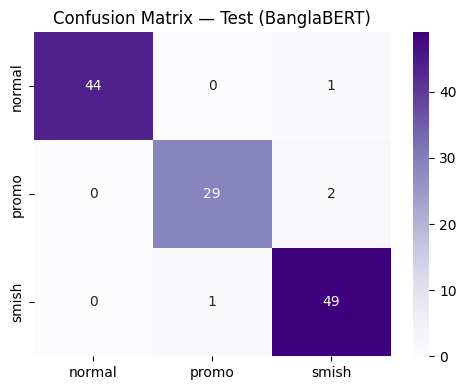

Smishing recall: 0.9800

Logged to /content/drive/MyDrive/Bangla_Smishing_Project/results/metrics.csv
Best model saved to /content/drive/MyDrive/Bangla_Smishing_Project/models/banglabert_dual_input/best_model.pt

FULL COMPARISON TABLE SO FAR
                                   model split  accuracy  macro_precision  macro_recall  macro_f1  smish_recall
TF-IDF + Logistic Regression (text only)  Test  0.895161         0.896076      0.895057  0.893254        0.9375
            TF-IDF + Structured Features  Test  0.951613              NaN           NaN  0.949962        0.9375
BanglaBERT (dual-input: text+structured)  Test  0.968254         0.969658      0.964421  0.966789        0.9800


In [ ]:
# ============================================================
# Cell 4 — Step 2: BanglaBERT (dual-input) fine-tuning
# Combines BanglaBERT text embeddings with the 34 scaled
# structured features. Requires GPU runtime (Runtime -> Change
# runtime type -> T4 GPU).
# ============================================================
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

TEXT_COL = "text_for_model"
LABEL_COL = "label_id"
ID2LABEL = {0: "normal", 1: "promo", 2: "smish"}
MODEL_NAME = "csebuetnlp/banglabert"
MAX_LENGTH = 128          # matches your preprocessing_config.json
BATCH_SIZE = 16            # small dataset -> smaller batch generalizes better
EPOCHS = 12
PATIENCE = 3               # early stopping patience (on val macro F1)
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
USE_STRUCTURED_FEATURES = True   # set False to run text-only BanglaBERT for comparison

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("⚠️  No GPU detected — go to Runtime > Change runtime type > T4 GPU, then re-run.")

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_clean.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_clean.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_clean.csv"))

SCALED_COLS = [c for c in train_df.columns if c.startswith("scaled_")]
NUM_STRUCT_FEATURES = len(SCALED_COLS) if USE_STRUCTURED_FEATURES else 0
print(f"Structured features: {NUM_STRUCT_FEATURES} ({'enabled' if USE_STRUCTURED_FEATURES else 'disabled'})")

# Load your teammate's already-saved tokenizer (fast, no download needed)
tokenizer = AutoTokenizer.from_pretrained(os.path.join(MODEL_DIR, "banglabert_tokenizer"))

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
class SmishingDataset(Dataset):
    def __init__(self, df):
        self.texts = df[TEXT_COL].tolist()
        self.labels = df[LABEL_COL].tolist()
        self.struct = df[SCALED_COLS].values.astype(np.float32) if USE_STRUCTURED_FEATURES else None

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }
        if USE_STRUCTURED_FEATURES:
            item["structured"] = torch.tensor(self.struct[idx], dtype=torch.float32)
        return item

train_loader = DataLoader(SmishingDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SmishingDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SmishingDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

# ------------------------------------------------------------
# Model: BanglaBERT [CLS] embedding + structured features -> classifier
# ------------------------------------------------------------
class DualInputBanglaBERT(nn.Module):
    def __init__(self, model_name, num_labels=3, num_struct_features=0, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        bert_hidden = self.bert.config.hidden_size
        self.use_structured = num_struct_features > 0

        if self.use_structured:
            self.struct_proj = nn.Sequential(
                nn.Linear(num_struct_features, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            combined_dim = bert_hidden + 32
        else:
            combined_dim = bert_hidden

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels),
        )

    def forward(self, input_ids, attention_mask, structured=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        cls_embedding = self.dropout(cls_embedding)

        if self.use_structured and structured is not None:
            struct_out = self.struct_proj(structured)
            combined = torch.cat([cls_embedding, struct_out], dim=1)
        else:
            combined = cls_embedding

        return self.classifier(combined)


model = DualInputBanglaBERT(
    MODEL_NAME, num_labels=3, num_struct_features=NUM_STRUCT_FEATURES
).to(device)

# ------------------------------------------------------------
# Class weights (imbalance: normal=361, promo=245, smish=396 in train)
# ------------------------------------------------------------
y_train = train_df[LABEL_COL].values
classes = np.array(sorted(np.unique(y_train)))
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(classes, weights)))

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

# ------------------------------------------------------------
# Train / eval loops
# ------------------------------------------------------------
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            structured = batch["structured"].to(device) if USE_STRUCTURED_FEATURES else None

            if train:
                optimizer.zero_grad()

            logits = model(input_ids, attention_mask, structured)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, macro_f1, all_preds, all_labels


# ------------------------------------------------------------
# Training loop with early stopping on val macro F1
# ------------------------------------------------------------
best_val_f1 = -1
patience_counter = 0
best_model_path = os.path.join(
    MODEL_DIR, "banglabert_dual_input" if USE_STRUCTURED_FEATURES else "banglabert_text_only"
)
os.makedirs(best_model_path, exist_ok=True)

history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1, _, _ = run_epoch(val_loader, train=False)

    print(f"Epoch {epoch}/{EPOCHS} | Train loss {train_loss:.4f} F1 {train_f1:.4f} | "
          f"Val loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}")
    history.append({"epoch": epoch, "train_loss": train_loss, "train_f1": train_f1,
                     "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(best_model_path, "best_model.pt"))
        print(f"  -> New best model saved (val F1 {val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no val F1 improvement for {PATIENCE} epochs)")
            break

# ------------------------------------------------------------
# Load best checkpoint and evaluate on test
# ------------------------------------------------------------
model.load_state_dict(torch.load(os.path.join(best_model_path, "best_model.pt")))

def evaluate_final(loader, split_name):
    _, acc, macro_f1, preds, labels = run_epoch(loader, train=False)
    precision, recall, _, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    print(f"\n=== {split_name} (BanglaBERT {'dual-input' if USE_STRUCTURED_FEATURES else 'text-only'}) ===")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(labels, preds, target_names=[ID2LABEL[i] for i in sorted(ID2LABEL)], zero_division=0))

    cm = confusion_matrix(labels, preds, labels=sorted(ID2LABEL))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)],
                yticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)])
    plt.title(f"Confusion Matrix — {split_name} (BanglaBERT)")
    plt.tight_layout()
    plt.show()

    labels_arr, preds_arr = np.array(labels), np.array(preds)
    smish_mask = (labels_arr == 2)
    smish_recall = (preds_arr[smish_mask] == 2).mean() if smish_mask.sum() else float("nan")
    print(f"Smishing recall: {smish_recall:.4f}")

    return {"split": split_name, "accuracy": acc, "macro_precision": precision,
            "macro_recall": recall, "macro_f1": macro_f1, "smish_recall": smish_recall}

val_metrics = evaluate_final(val_loader, "Validation")
test_metrics = evaluate_final(test_loader, "Test")

# ------------------------------------------------------------
# Log results
# ------------------------------------------------------------
model_label = f"BanglaBERT {'(dual-input: text+structured)' if USE_STRUCTURED_FEATURES else '(text-only)'}"
row = {"model": model_label, **test_metrics}
results_path = os.path.join(RESULTS_DIR, "metrics.csv")
prior = pd.read_csv(results_path)
results_df = pd.concat([prior, pd.DataFrame([row])], ignore_index=True)
results_df.to_csv(results_path, index=False)
print(f"\nLogged to {results_path}")
print(f"Best model saved to {best_model_path}/best_model.pt")

print("\n" + "="*50)
print("FULL COMPARISON TABLE SO FAR")
print("="*50)
print(results_df.to_string(index=False))


=== Validation FINAL (leakage-free, BanglaBERT dual-input) ===
Accuracy: 0.9839 | Macro F1: 0.9821
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99        45
       promo       0.97      0.97      0.97        31
       smish       1.00      0.98      0.99        48

    accuracy                           0.98       124
   macro avg       0.98      0.98      0.98       124
weighted avg       0.98      0.98      0.98       124



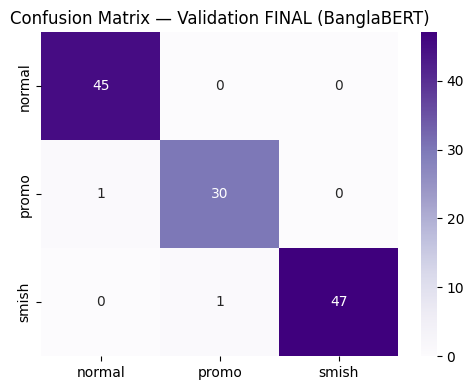

Smishing recall: 0.9792

=== Test FINAL (leakage-free, BanglaBERT dual-input) ===
Accuracy: 0.9677 | Macro F1: 0.9663
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99        45
       promo       0.97      0.94      0.95        31
       smish       0.94      0.98      0.96        48

    accuracy                           0.97       124
   macro avg       0.97      0.96      0.97       124
weighted avg       0.97      0.97      0.97       124



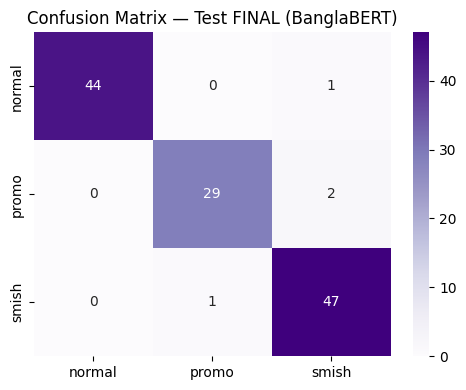

Smishing recall: 0.9792

Logged to /content/drive/MyDrive/Bangla_Smishing_Project/results/metrics.csv

FULL COMPARISON TABLE (all runs so far)
                                       model split  accuracy  macro_precision  macro_recall  macro_f1  smish_recall
    TF-IDF + Logistic Regression (text only)  Test  0.895161         0.896076      0.895057  0.893254      0.937500
                TF-IDF + Structured Features  Test  0.951613              NaN           NaN  0.949962      0.937500
    BanglaBERT (dual-input: text+structured)  Test  0.968254         0.969658      0.964421  0.966789      0.980000
BanglaBERT (dual-input) - FINAL leakage-free  Test  0.967742         0.968889      0.964143  0.966256      0.979167


In [ ]:
# ============================================================
# Cell 7 — Re-evaluate saved BanglaBERT checkpoint on clean splits
# No retraining needed — reuses the model class/tokenizer from Cell 4.
# Run this in the SAME session as Cell 4 (model class + tokenizer
# already defined). If you restarted the runtime, re-run Cell 4's
# imports/class definitions first (you don't need to re-run training).
# ============================================================
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
TEXT_COL = "text_for_model"
LABEL_COL = "label_id"
ID2LABEL = {0: "normal", 1: "promo", 2: "smish"}

# ------------------------------------------------------------
# Load the clean final splits
# ------------------------------------------------------------
val_final = pd.read_csv(os.path.join(DATA_DIR, "val_final.csv"))
test_final = pd.read_csv(os.path.join(DATA_DIR, "test_final.csv"))

# Build loaders using the SAME SmishingDataset class from Cell 4
val_loader_final = DataLoader(SmishingDataset(val_final), batch_size=BATCH_SIZE, shuffle=False)
test_loader_final = DataLoader(SmishingDataset(test_final), batch_size=BATCH_SIZE, shuffle=False)

# ------------------------------------------------------------
# Reload best checkpoint (in case memory was cleared / new session)
# ------------------------------------------------------------
best_model_path = os.path.join(MODEL_DIR, "banglabert_dual_input")
model.load_state_dict(torch.load(os.path.join(best_model_path, "best_model.pt")))
model.eval()

# ------------------------------------------------------------
# Evaluate (reuses run_epoch from Cell 4)
# ------------------------------------------------------------
def evaluate_clean(loader, split_name):
    _, acc, macro_f1, preds, labels = run_epoch(loader, train=False)
    precision, recall, _, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    print(f"\n=== {split_name} FINAL (leakage-free, BanglaBERT dual-input) ===")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(labels, preds, target_names=[ID2LABEL[i] for i in sorted(ID2LABEL)], zero_division=0))

    cm = confusion_matrix(labels, preds, labels=sorted(ID2LABEL))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)],
                yticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)])
    plt.title(f"Confusion Matrix — {split_name} FINAL (BanglaBERT)")
    plt.tight_layout()
    plt.show()

    labels_arr, preds_arr = np.array(labels), np.array(preds)
    smish_mask = (labels_arr == 2)
    smish_recall = (preds_arr[smish_mask] == 2).mean() if smish_mask.sum() else float("nan")
    print(f"Smishing recall: {smish_recall:.4f}")

    return {"split": split_name, "accuracy": acc, "macro_precision": precision,
            "macro_recall": recall, "macro_f1": macro_f1, "smish_recall": smish_recall}

val_metrics_final = evaluate_clean(val_loader_final, "Validation")
test_metrics_final = evaluate_clean(test_loader_final, "Test")

# ------------------------------------------------------------
# Log as the FINAL, leakage-free result (separate row from the earlier one)
# ------------------------------------------------------------
row = {"model": "BanglaBERT (dual-input) - FINAL leakage-free", **test_metrics_final}
results_path = os.path.join(RESULTS_DIR, "metrics.csv")
prior = pd.read_csv(results_path)
results_df = pd.concat([prior, pd.DataFrame([row])], ignore_index=True)
results_df.to_csv(results_path, index=False)
print(f"\nLogged to {results_path}")

print("\n" + "="*60)
print("FULL COMPARISON TABLE (all runs so far)")
print("="*60)
print(results_df.to_string(index=False))

In [ ]:
# ============================================================
# Cell 5 — Sanity checks: leakage, overfitting gap, error inspection
# ============================================================
import os
import pandas as pd
import torch
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
TEXT_COL = "text_for_model"
LABEL_COL = "label_id"
ID2LABEL = {0: "normal", 1: "promo", 2: "smish"}

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_clean.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_clean.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_clean.csv"))

# ------------------------------------------------------------
# 1. Exact-duplicate leakage check across splits
# ------------------------------------------------------------
train_texts = set(train_df[TEXT_COL].str.strip())
val_texts = set(val_df[TEXT_COL].str.strip())
test_texts = set(test_df[TEXT_COL].str.strip())

train_val_overlap = train_texts & val_texts
train_test_overlap = train_texts & test_texts
val_test_overlap = val_texts & test_texts

print("=== Exact-duplicate leakage check ===")
print(f"Train/Val overlap:  {len(train_val_overlap)} messages")
print(f"Train/Test overlap: {len(train_test_overlap)} messages")
print(f"Val/Test overlap:   {len(val_test_overlap)} messages")
if train_test_overlap:
    print("⚠️  Leakage found! Example overlapping messages:")
    for t in list(train_test_overlap)[:3]:
        print("  -", t[:80])
else:
    print("✅ No exact-duplicate leakage between train and test.")

# ------------------------------------------------------------
# 2. Near-duplicate check (simple: same text after removing spaces/punctuation)
#    Catches near-identical smishing templates with only a phone number/URL changed
# ------------------------------------------------------------
import re
def normalize_for_dup_check(t):
    return re.sub(r'\s+', '', re.sub(r'[^\w\s]', '', str(t))).lower()

train_norm = set(train_df[TEXT_COL].apply(normalize_for_dup_check))
test_norm = test_df[TEXT_COL].apply(normalize_for_dup_check)
near_dup_mask = test_norm.isin(train_norm)
print(f"\n=== Near-duplicate check (punctuation/whitespace-insensitive) ===")
print(f"Test messages that are near-duplicates of a train message: {near_dup_mask.sum()} / {len(test_df)}")
if near_dup_mask.sum() > 0:
    print("These rows (if many) could be inflating test accuracy:")
    print(test_df.loc[near_dup_mask, [TEXT_COL, LABEL_COL]].head(10))

# ------------------------------------------------------------
# 3. Train accuracy vs test accuracy (run this AFTER loading your
#    trained model from Cell 4 — reuses the same model/loaders in memory)
# ------------------------------------------------------------
# If model/train_loader are still in memory from Cell 4, this block works directly.
# Otherwise, re-run Cell 4 first, or reload the checkpoint:
#
# model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "banglabert_dual_input", "best_model.pt")))

try:
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=False)
    print(f"\n=== Train vs Test performance gap ===")
    print(f"Train accuracy: {train_acc:.4f} | Train macro F1: {train_f1:.4f}")
    print(f"Test accuracy:  {test_metrics['accuracy']:.4f} | Test macro F1: {test_metrics['macro_f1']:.4f}")
    gap = train_acc - test_metrics['accuracy']
    print(f"Gap: {gap:.4f}  {'(large gap — likely overfitting)' if gap > 0.05 else '(small gap — looks healthy)'}")
except NameError:
    print("\n(Skipping train-vs-test gap check — model/train_loader not in memory. "
          "Re-run this cell right after Cell 4 without restarting the runtime.)")

# ------------------------------------------------------------
# 4. Manually inspect every misclassified test example
# ------------------------------------------------------------
try:
    _, _, _, test_preds, test_labels = run_epoch(test_loader, train=False)
    test_df_display = test_df.copy().reset_index(drop=True)
    test_df_display["predicted_id"] = test_preds
    test_df_display["true_label"] = test_df_display[LABEL_COL].map(ID2LABEL)
    test_df_display["predicted_label"] = test_df_display["predicted_id"].map(ID2LABEL)

    errors = test_df_display[test_df_display[LABEL_COL] != test_df_display["predicted_id"]]
    print(f"\n=== Misclassified test examples: {len(errors)} / {len(test_df_display)} ===")
    for _, row in errors.iterrows():
        print(f"\nTrue: {row['true_label']}  |  Predicted: {row['predicted_label']}")
        print(f"Text: {row[TEXT_COL]}")
        print(f"has_url={row.get('has_url', 'NA')}  url_count={row.get('url_count', 'NA')}  "
              f"security_keyword_count={row.get('security_keyword_count', 'NA')}")
except NameError:
    print("\n(Skipping error inspection — run this right after Cell 4.)")


=== Exact-duplicate leakage check ===
Train/Val overlap:  1 messages
Train/Test overlap: 2 messages
Val/Test overlap:   0 messages
⚠️  Leakage found! Example overlapping messages:
  - জনতা ব্যাংক থেকে জরুরি বার্তা। বিস্তারিত জানতে এখানে ক্লিক করুন:  [URL]
  - আপনার পেমেন্টটি প্রক্রিয়া করতে আমাদের আপনার তথ্য প্রয়োজন। এখানে ক্লিক করুন: [ 

=== Near-duplicate check (punctuation/whitespace-insensitive) ===
Test messages that are near-duplicates of a train message: 2 / 126
These rows (if many) could be inflating test accuracy:
                                       text_for_model  label_id
11  আপনার পেমেন্টটি প্রক্রিয়া করতে আমাদের আপনার ত...         2
16  জনতা ব্যাংক থেকে জরুরি বার্তা। বিস্তারিত জানতে...         2

(Skipping train-vs-test gap check — model/train_loader not in memory. Re-run this cell right after Cell 4 without restarting the runtime.)

(Skipping error inspection — run this right after Cell 4.)


In [ ]:
# ============================================================
# Cell 6 — Fix leakage: remove val/test rows that duplicate train
# Keeps the copy in train (larger split), drops from val/test.
# ============================================================
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
TEXT_COL = "text_for_model"
LABEL_COL = "label_id"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_clean.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_clean.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_clean.csv"))

train_texts = set(train_df[TEXT_COL].str.strip())

def drop_leaked_rows(df, name):
    is_leaked = df[TEXT_COL].str.strip().isin(train_texts)
    n_leaked = is_leaked.sum()
    if n_leaked > 0:
        print(f"{name}: removing {n_leaked} row(s) that duplicate train")
        print(df.loc[is_leaked, [TEXT_COL, LABEL_COL]].to_string(index=False))
    df_clean = df.loc[~is_leaked].reset_index(drop=True)
    print(f"{name}: {len(df)} -> {len(df_clean)} rows\n")
    return df_clean

val_final = drop_leaked_rows(val_df, "val")
test_final = drop_leaked_rows(test_df, "test")

# ------------------------------------------------------------
# Confirm label balance didn't shift meaningfully
# ------------------------------------------------------------
print("val_final label counts:", val_final[LABEL_COL].value_counts().to_dict())
print("test_final label counts:", test_final[LABEL_COL].value_counts().to_dict())

val_final.to_csv(os.path.join(DATA_DIR, "val_final.csv"), index=False)
test_final.to_csv(os.path.join(DATA_DIR, "test_final.csv"), index=False)
print("\nSaved val_final.csv and test_final.csv (leakage-free) to Drive.")
print("train_clean.csv is unchanged — the duplicate rows stay there.")

val: removing 1 row(s) that duplicate train
                                                              text_for_model  label_id
আপনার অ্যাকাউন্টে সন্দেহজনক কার্যকলাপ হয়েছে। লগইন করে যাচাই করুন: [ [URL] ]         2
val: 125 -> 124 rows

test: removing 2 row(s) that duplicate train
                                                                         text_for_model  label_id
আপনার পেমেন্টটি প্রক্রিয়া করতে আমাদের আপনার তথ্য প্রয়োজন। এখানে ক্লিক করুন: [ [URL] ]         2
               জনতা ব্যাংক থেকে জরুরি বার্তা। বিস্তারিত জানতে এখানে ক্লিক করুন:  [URL]          2
test: 126 -> 124 rows

val_final label counts: {2: 48, 0: 45, 1: 31}
test_final label counts: {2: 48, 0: 45, 1: 31}

Saved val_final.csv and test_final.csv (leakage-free) to Drive.
train_clean.csv is unchanged — the duplicate rows stay there.


Baseline macro F1: 0.9663

Top 10 most important structured features:
                feature  f1_drop_when_shuffled
       scaled_url_count                    0.0
scaled_url_total_length                    0.0
  scaled_url_max_length                    0.0
 scaled_url_digit_count                    0.0
   scaled_url_dot_count                    0.0
scaled_url_hyphen_count                    0.0
 scaled_url_slash_count                    0.0
   scaled_url_has_https                    0.0
      scaled_url_has_ip                    0.0
      scaled_url_has_at                    0.0


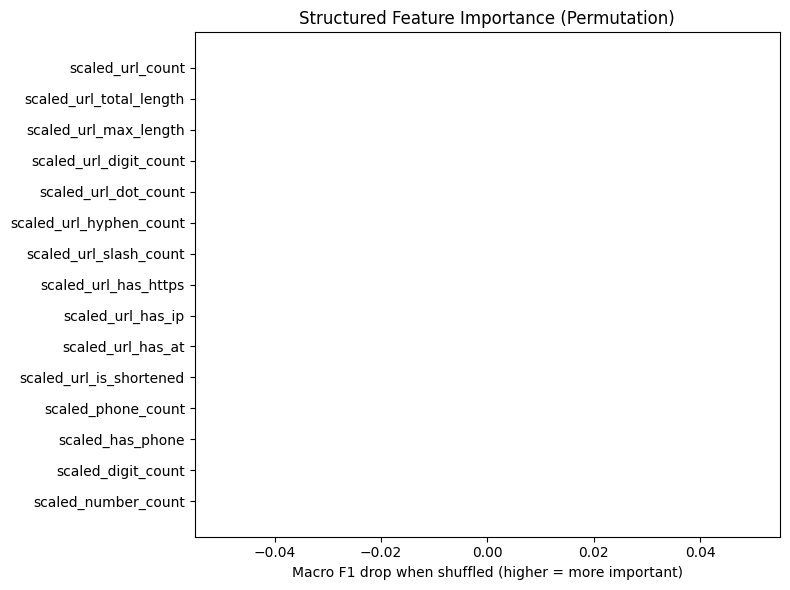


Saved to /content/drive/MyDrive/Bangla_Smishing_Project/results/structured_feature_importance.csv

Row 0 | True label: normal
Text: আপনার পাওনা ৬০০০/- টাকা, দ্রুত পরিশোধ করুন।
Top contributing words (word: weight toward predicted class):
  ওন: -0.0018
  পর: -0.0013
  আপন: +0.0009
  ক: -0.0007
  দ: -0.0007
  ট: -0.0006
  র: +0.0003
  ৬০০০: +0.0003

Row 1 | True label: smish
Text: বাংলাদেশ ব্যাংক অ্যাকাউন্ট আপডেট করতে কল করুন: +8801813344556
Top contributing words (word: weight toward predicted class):
  8801813344556: -0.0033
  কর: -0.0025
  আপড: -0.0016
  উন: -0.0015
  য: -0.0015
  অ: -0.0013
  কল: -0.0010
  ন: -0.0009

Row 2 | True label: promo
Text: স্মার্টফোনে মেগা ডিসকাউন্ট! Samsung, Xiaomi এ ২৫০০০ টাকা পর্যন্ত ছাড়।
Top contributing words (word: weight toward predicted class):
  ড: +0.3309
  উন: +0.1352
  গ: +0.1187
  সক: +0.1077
  র: +0.0966
  ট: +0.0907
  ছ: +0.0859
  ম: +0.0820

Row 11 | True label: normal
Text: খালু, আপনার ছেলে কেমন আছে? পড়াশুনা ভালো চলছে?
Top contributing w

In [ ]:
# ============================================================
# Cell 8 — Explainability
# Part A: permutation importance for the 34 structured features
# Part B: LIME word-level explanations for individual messages
# Run in the SAME session as Cell 4/7 (needs model, tokenizer, etc.)
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
TEXT_COL = "text_for_model"
LABEL_COL = "label_id"
ID2LABEL = {0: "normal", 1: "promo", 2: "smish"}

test_final = pd.read_csv(os.path.join(DATA_DIR, "test_final.csv"))
SCALED_COLS = [c for c in test_final.columns if c.startswith("scaled_")]

model.eval()

# ------------------------------------------------------------
# PART A — Permutation importance for structured features
# Shuffle one structured column at a time across the test set,
# measure how much macro F1 drops. Bigger drop = more important.
# ------------------------------------------------------------
from sklearn.metrics import f1_score

def predict_batch(texts, structured_array):
    """Run the dual-input model on a list of texts + matching structured feature rows."""
    preds = []
    bs = 16
    for i in range(0, len(texts), bs):
        batch_texts = texts[i:i+bs]
        batch_struct = structured_array[i:i+bs]
        enc = tokenizer(batch_texts, max_length=MAX_LENGTH, padding="max_length",
                         truncation=True, return_tensors="pt")
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        structured = torch.tensor(batch_struct, dtype=torch.float32).to(device)
        with torch.no_grad():
            logits = model(input_ids, attention_mask, structured)
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    return np.array(preds)

texts = test_final[TEXT_COL].tolist()
struct = test_final[SCALED_COLS].values.astype(np.float32)
y_true = test_final[LABEL_COL].values

baseline_preds = predict_batch(texts, struct)
baseline_f1 = f1_score(y_true, baseline_preds, average="macro")
print(f"Baseline macro F1: {baseline_f1:.4f}\n")

importances = {}
rng = np.random.default_rng(42)
for i, col in enumerate(SCALED_COLS):
    struct_shuffled = struct.copy()
    rng.shuffle(struct_shuffled[:, i])  # shuffle only this column
    preds = predict_batch(texts, struct_shuffled)
    f1 = f1_score(y_true, preds, average="macro")
    importances[col] = baseline_f1 - f1  # positive = feature mattered

imp_df = pd.DataFrame(sorted(importances.items(), key=lambda x: -x[1]),
                       columns=["feature", "f1_drop_when_shuffled"])
print("Top 10 most important structured features:")
print(imp_df.head(10).to_string(index=False))

plt.figure(figsize=(8, 6))
top15 = imp_df.head(15)
plt.barh(top15["feature"][::-1], top15["f1_drop_when_shuffled"][::-1])
plt.xlabel("Macro F1 drop when shuffled (higher = more important)")
plt.title("Structured Feature Importance (Permutation)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "structured_feature_importance.png"))
plt.show()

imp_df.to_csv(os.path.join(RESULTS_DIR, "structured_feature_importance.csv"), index=False)
print(f"\nSaved to {RESULTS_DIR}/structured_feature_importance.csv")

# ------------------------------------------------------------
# PART B — LIME word-level explanations
# For a given row, structured features are held FIXED at that
# row's real values while LIME perturbs only the text.
# ------------------------------------------------------------
try:
    import lime
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "lime"])
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=[ID2LABEL[i] for i in range(3)])

def make_predict_fn_for_row(fixed_structured_row):
    """Returns a predict_proba-style function with structured features held constant,
    so LIME can isolate the effect of text alone for this specific message."""
    def predict_fn(text_list):
        struct_batch = np.tile(fixed_structured_row, (len(text_list), 1))
        bs = 16
        all_probs = []
        for i in range(0, len(text_list), bs):
            batch_texts = text_list[i:i+bs]
            batch_struct = struct_batch[i:i+bs]
            enc = tokenizer(batch_texts, max_length=MAX_LENGTH, padding="max_length",
                             truncation=True, return_tensors="pt")
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            structured = torch.tensor(batch_struct, dtype=torch.float32).to(device)
            with torch.no_grad():
                logits = model(input_ids, attention_mask, structured)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
        return np.vstack(all_probs)
    return predict_fn

# Explain a few interesting rows: pick 2 correct predictions + the 3 known errors
sample_indices = list(range(3)) + [11, 16]  # adjust indices as needed, or pick manually
sample_indices = [i for i in sample_indices if i < len(test_final)]

for idx in sample_indices:
    row = test_final.iloc[idx]
    text = row[TEXT_COL]
    true_label = ID2LABEL[row[LABEL_COL]]
    fixed_struct = row[SCALED_COLS].values.astype(np.float32)

    predict_fn = make_predict_fn_for_row(fixed_struct)
    exp = explainer.explain_instance(text, predict_fn, num_features=8, num_samples=200)

    print(f"\n{'='*60}\nRow {idx} | True label: {true_label}\nText: {text}")
    print("Top contributing words (word: weight toward predicted class):")
    for word, weight in exp.as_list():
        print(f"  {word}: {weight:+.4f}")

In [ ]:
# ============================================================
# Cell 8 — Final comparison table (your models + literature)
# ============================================================
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Bangla_Smishing_Project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

your_results = pd.read_csv(os.path.join(RESULTS_DIR, "metrics.csv"))

# Keep only the final, leakage-free rows (dedupe by model name, keep last occurrence)
your_results = your_results.drop_duplicates(subset="model", keep="last")
print("Your results:")
print(your_results[["model", "accuracy", "macro_f1"]].to_string(index=False))

# ------------------------------------------------------------
# Published benchmarks (fill in exact numbers from the papers'
# abstracts/results tables — cite each paper properly in your report)
# ------------------------------------------------------------
literature = pd.DataFrame([
    {"model": "BERT + Char-CNN Hybrid (published)", "accuracy": 0.9847, "macro_f1": None,
     "note": "3-class, ~2287 messages, different dataset"},
    {"model": "BanglaBERT + XGBoost / NirapodBarta (published)", "accuracy": None, "macro_f1": None,
     "note": "Multiclass, BanglaBarta dataset (Mendeley) — check paper for exact reported metric"},
    {"model": "BiLSTM-based (published)", "accuracy": None, "macro_f1": None,
     "note": "Check paper for exact reported metric"},
])

# ------------------------------------------------------------
# Combined table
# ------------------------------------------------------------
your_results["note"] = "This project, 1253-message dataset (1002/125/126 split)"
combined = pd.concat([
    your_results[["model", "accuracy", "macro_f1", "note"]],
    literature
], ignore_index=True)

print("\n" + "="*70)
print("FINAL COMPARISON TABLE")
print("="*70)
print(combined.to_string(index=False))

combined.to_csv(os.path.join(RESULTS_DIR, "final_comparison_table.csv"), index=False)

# Also save as a markdown table, ready to paste into your report/README
md_lines = ["| Model | Accuracy | Macro F1 | Note |", "|---|---|---|---|"]
for _, row in combined.iterrows():
    acc = f"{row['accuracy']:.4f}" if pd.notna(row['accuracy']) else "—"
    f1 = f"{row['macro_f1']:.4f}" if pd.notna(row['macro_f1']) else "—"
    md_lines.append(f"| {row['model']} | {acc} | {f1} | {row['note']} |")

md_table = "\n".join(md_lines)
with open(os.path.join(RESULTS_DIR, "final_comparison_table.md"), "w", encoding="utf-8") as f:
    f.write(md_table)

print(f"\nSaved to {RESULTS_DIR}/final_comparison_table.csv and .md")
print("\nMarkdown preview:\n")
print(md_table)

Your results:
                                       model  accuracy  macro_f1
    TF-IDF + Logistic Regression (text only)  0.895161  0.893254
                TF-IDF + Structured Features  0.951613  0.949962
    BanglaBERT (dual-input: text+structured)  0.968254  0.966789
BanglaBERT (dual-input) - FINAL leakage-free  0.967742  0.966256

FINAL COMPARISON TABLE
                                          model  accuracy  macro_f1                                                                               note
       TF-IDF + Logistic Regression (text only)  0.895161  0.893254                            This project, 1253-message dataset (1002/125/126 split)
                   TF-IDF + Structured Features  0.951613  0.949962                            This project, 1253-message dataset (1002/125/126 split)
       BanglaBERT (dual-input: text+structured)  0.968254  0.966789                            This project, 1253-message dataset (1002/125/126 split)
   BanglaBERT (dual-input) - FINA

/tmp/ipykernel_781/1955765609.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([
